# Import

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score, classification_report
import os
import cv2
import matplotlib.pyplot as plt
import re
import glob
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from keras.optimizers import Adam
import tensorflow as tf
from keras import layers
from time import perf_counter
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from keras.layers import Conv1D
from keras.layers import GlobalMaxPooling1D
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, classification_report

# Install the data

In [ ]:
!pip install kaggle
!mkdir ~/.kaggle
!echo '{"username":"ddooaa","key":"ad34e26f23cde872895a312699b13bbc"}' > ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d dareenalharthi/jamalon-arabic-books-dataset
!unzip /content/jamalon-arabic-books-dataset.zip

mkdir: cannot create directory ‘/root/.kaggle’: File exists
Dataset URL: https://www.kaggle.com/datasets/dareenalharthi/jamalon-arabic-books-dataset
License(s): other
jamalon-arabic-books-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  /content/jamalon-arabic-books-dataset.zip
replace jamalon dataset.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: N


# Data Preprocessing

In [ ]:
import pandas as pd

# Read the dataset
df = pd.read_csv('/content/jamalon dataset.csv')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8986 entries, 0 to 8985
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        8986 non-null   int64  
 1   Title             8986 non-null   object 
 2   Author            8986 non-null   object 
 3   Description       8412 non-null   object 
 4   Pages             8986 non-null   int64  
 5   Publication year  8986 non-null   int64  
 6   Publisher         8986 non-null   object 
 7   Cover             8986 non-null   object 
 8   Category          8986 non-null   object 
 9   Subcategory       8986 non-null   object 
 10  Price             8986 non-null   float64
dtypes: float64(1), int64(3), object(7)
memory usage: 772.4+ KB


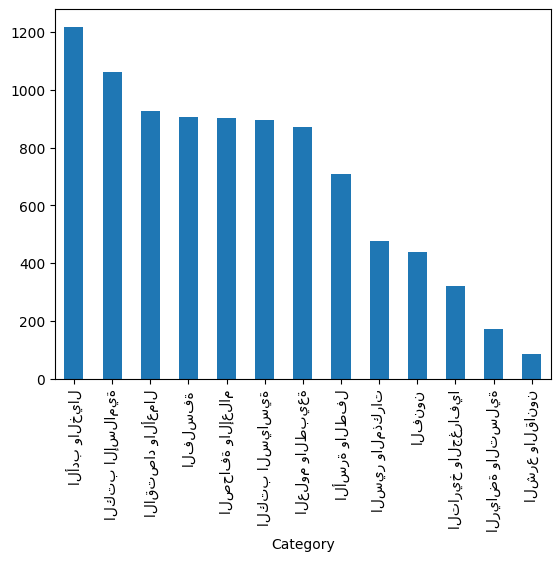

In [ ]:
# Group by category and count the number of books in each category
category_counts = df.groupby('Category').size()
category_counts.sort_values(ascending=False, inplace=True)

# Plot the results
category_counts.plot(kind='bar')
plt.show()

In [ ]:
# Drop rows based on column value across the entire dataset
df = df.drop(df[df['Category'] == 'الأدب والخيال'].index)
df = df.drop(df[df['Category'] == 'الكتب الإسلامية'].index)
df = df.drop(df[df['Category'] == 'السير والمذكرات'].index)
df = df.drop(df[df['Category'] == 'التاريخ والجغرافيا'].index)
df = df.drop(df[df['Category'] == 'الأسرة والطفل'].index)
df = df.drop(df[df['Category'] == 'الشرع والقانون'].index)
df = df.drop(df[df['Category'] == 'الفنون'].index)
df = df.drop(df[df['Category'] == 'الرياضة والتسلية'].index)

df

,Unnamed: 0,Title,Author,Description,Pages,Publication year,Publisher,Cover,Category,Subcategory,Price
2249,3450,1982 عام الاجتياح - لبنان والقدس والجولان في ...,غسان تويني,None,478,0,دار النهار للنشر والتوزيع,غلاف عادي,الكتب السياسية,السياسة الدولية,61.88
2250,3451,المنظمات الدولية,سهيل حسين الفتلاوي,None,367,0,دار الفكر العربي للطباعة والنشر,غلاف كرتوني,الكتب السياسية,السياسة الدولية,45.00
2251,3452,مدخل إلى علم العلاقات الدولية,محمد طه بدوي,None,304,0,دار النهضة العربية للطباعة والنشر والتوزيع,غلاف عادي,الكتب السياسية,السياسة الدولية,45.00
2252,3454,الاستعمار الفرنسي في الجزائر سياسية التفكيك ا...,عدي الهواري,أشار العديد من المفكرين إلى ركود المغرب القرو...,224,0,دار الحداثة للطباعة والنشر,غلاف عادي,الكتب السياسية,السياسة الدولية,52.50
2253,3461,ترهات أوليسيوس,بول راسينييه,الكاتب الفرنسي بول راسينييه عمل في صفوف المقا...,312,0,دار الذاكرة للطباعة والنشر والتوزيع,غلاف عادي,الكتب السياسية,السياسة الدولية,26.25
...,...,...,...,...,...,...,...,...,...,...,...
8503,10518,ما الجمالية؟,مارك جيمينيز,"ما الجمالية؟"" لمارك جيمينيز كتاب -مرجع في درس ...",480,2006,مؤسسة الانتشار العربي,غلاف عادي,الفلسفة,فلسفة العلوم,22.50
8504,10519,فلسفة العلم : بحوث متقدمة في فلسفة الفيزياء وا...,صلاح الجابري,قد يعلم كثير من الناس، مثقفين وغير مثقفين، بطر...,176,1983,دار الحداثة للطباعة والنشر,غلاف عادي,الفلسفة,فلسفة العلوم,168.76
8505,10520,ما هي الابستمولوجيا؟,محمد وقيدي,NaN,221,2003,دار الفكر المعاصر,غلاف كرتوني,الفلسفة,فلسفة العلوم,105.01
8506,10521,موجز تاريخ الكون : من الانفجار الأعظم إلى الاس...,هاني رزق,إن هذا الكتاب الموجز تثقيفي الغرض، علمي الهدف،...,447,2010,دار التنوير للطباعة والنشر والتوزيع,غلاف ورقي,الفلسفة,فلسفة العلوم,30.00


In [ ]:
df = df[['Title', 'Category']]
df

,Title,Category
2249,1982 عام الاجتياح - لبنان والقدس والجولان في ...,الكتب السياسية
2250,المنظمات الدولية,الكتب السياسية
2251,مدخل إلى علم العلاقات الدولية,الكتب السياسية
2252,الاستعمار الفرنسي في الجزائر سياسية التفكيك ا...,الكتب السياسية
2253,ترهات أوليسيوس,الكتب السياسية
...,...,...
8503,ما الجمالية؟,الفلسفة
8504,فلسفة العلم : بحوث متقدمة في فلسفة الفيزياء وا...,الفلسفة
8505,ما هي الابستمولوجيا؟,الفلسفة
8506,موجز تاريخ الكون : من الانفجار الأعظم إلى الاس...,الفلسفة


In [ ]:
#check1-presence of null values
df.isnull().sum()

Title       0
Category    0
dtype: int64

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4501 entries, 2249 to 8507
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Title     4501 non-null   object
 1   Category  4501 non-null   object
dtypes: object(2)
memory usage: 105.5+ KB


In [ ]:
df.describe()

,Title,Category
count,4501,4501
unique,4066,5
top,دور المنظمات الدولية غير الحكومية في عمليات ب...,الاقتصاد والأعمال
freq,13,928


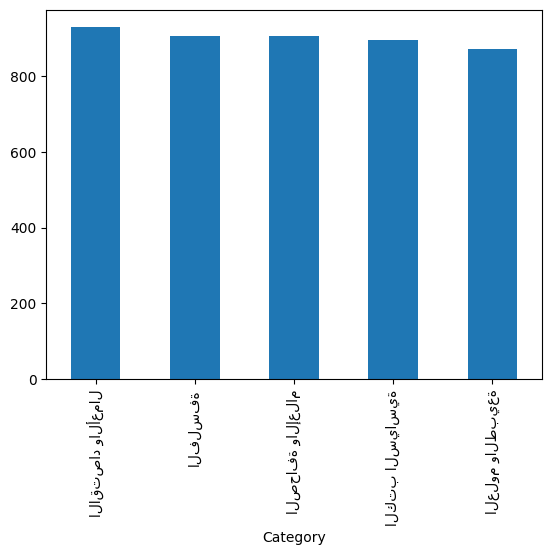

In [ ]:
# Group by category and count the number of books in each category
category_counts = df.groupby('Category').size()
category_counts.sort_values(ascending=False, inplace=True)

# Plot the results
category_counts.plot(kind='bar')
plt.show()

In [ ]:
unique_categories = df['Category'].unique()
print(unique_categories)

['الكتب السياسية' 'العلوم والطبيعة' 'الاقتصاد والأعمال' 'الصحافة والإعلام'
 'الفلسفة']


# Split the dataset

In [ ]:
x = df['Title']
y = df['Category']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

# Create TF-IDF vectorizer and transform the training data
vectorizer = TfidfVectorizer()
X_train_vectors = vectorizer.fit_transform(X_train)

# Machine Learning

# SVM

In [ ]:
# Train the SVM model
svm = SVC(kernel='linear')
svm.fit(X_train_vectors, y_train)

# Transform the testing data and make predictions
X_test_vectors = vectorizer.transform(X_test)
y_pred = svm.predict(X_test_vectors)

# Transform the training data and make predictions
X_train_vectors = vectorizer.transform(X_train)
y_train_pred = svm.predict(X_train_vectors)

# Evaluate the accuracy of the model
train_accuracy = accuracy_score(y_train, y_train_pred)
print("Train Accuracy:", train_accuracy)

# Evaluate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy:", accuracy)
# Compute precision, recall, and F1-score
report = classification_report(y_test, y_pred)
print(report)

Train Accuracy: 0.9747222222222223
Test Accuracy: 0.7547169811320755
                   precision    recall  f1-score   support

الاقتصاد والأعمال       0.79      0.76      0.78       191
 الصحافة والإعلام       0.74      0.70      0.72       157
  العلوم والطبيعة       0.82      0.78      0.80       181
          الفلسفة       0.70      0.77      0.73       184
   الكتب السياسية       0.72      0.76      0.74       188

         accuracy                           0.75       901
        macro avg       0.76      0.75      0.75       901
     weighted avg       0.76      0.75      0.76       901



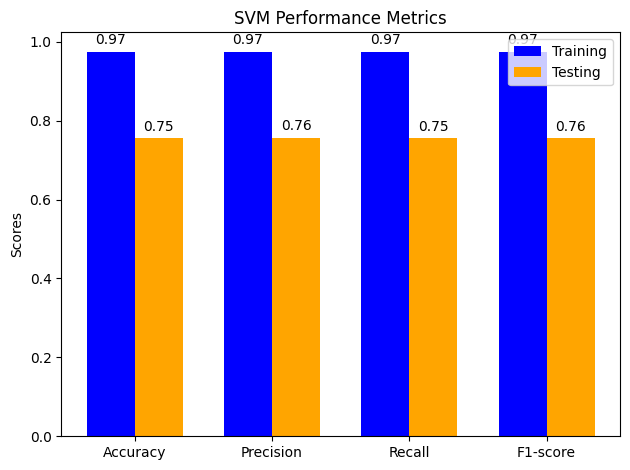

In [ ]:
# Compute precision, recall, and F1-score for training data
train_precision, train_recall, train_f1, _ = precision_recall_fscore_support(y_train, y_train_pred, average='weighted')

# Compute precision, recall, and F1-score for testing data
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')

# Plot the results
labels = ['Accuracy', 'Precision', 'Recall', 'F1-score']
train_scores = [train_accuracy, train_precision, train_recall, train_f1]
test_scores = [accuracy, precision, recall, f1]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots()
train_rects = ax.bar(x - width/2, train_scores, width, label='Training',color='blue')
test_rects = ax.bar(x + width/2, test_scores, width, label='Testing',color='orange')

ax.set_ylabel('Scores')
ax.set_title('SVM Performance Metrics')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate('{:.2f}'.format(height),
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(train_rects)
autolabel(test_rects)

fig.tight_layout()

plt.show()

# Logistic Regression

In [ ]:
# Train the logistic regression model
logreg = LogisticRegression()
logreg.fit(X_train_vectors, y_train)

# Transform the testing data and make predictions
X_test_vectors = vectorizer.transform(X_test)
y_pred = logreg.predict(X_test_vectors)

# Transform the training data and make predictions
X_train_vectors = vectorizer.transform(X_train)
y_train_pred = logreg.predict(X_train_vectors)

# Evaluate the train accuracy of the model
train_accuracy = accuracy_score(y_train, y_train_pred)
print("Train Accuracy:", train_accuracy)

# Evaluate the test accuracy of the model
accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy:", accuracy)
# Compute precision, recall, and F1-score
report = classification_report(y_test, y_pred)
print(report)

Train Accuracy: 0.9619444444444445
Test Accuracy: 0.753607103218646
                   precision    recall  f1-score   support

الاقتصاد والأعمال       0.80      0.75      0.78       191
 الصحافة والإعلام       0.75      0.69      0.72       157
  العلوم والطبيعة       0.75      0.82      0.79       181
          الفلسفة       0.75      0.76      0.75       184
   الكتب السياسية       0.72      0.74      0.73       188

         accuracy                           0.75       901
        macro avg       0.75      0.75      0.75       901
     weighted avg       0.75      0.75      0.75       901



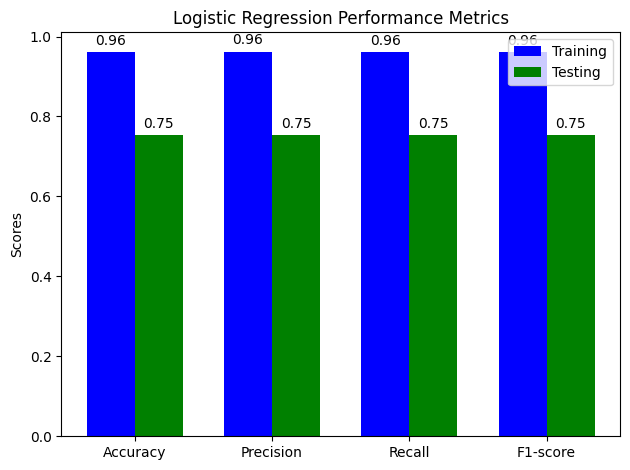

In [ ]:
# Compute precision, recall, and F1-score for training data
train_precision, train_recall, train_f1, _ = precision_recall_fscore_support(y_train, y_train_pred, average='weighted')

# Compute precision, recall, and F1-score for testing data
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')

# Plot the results
labels = ['Accuracy', 'Precision', 'Recall', 'F1-score']
train_scores = [train_accuracy, train_precision, train_recall, train_f1]
test_scores = [accuracy, precision, recall, f1]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots()
train_rects = ax.bar(x - width/2, train_scores, width, label='Training',color='blue')
test_rects = ax.bar(x + width/2, test_scores, width, label='Testing',color='green')

ax.set_ylabel('Scores')
ax.set_title('Logistic Regression Performance Metrics')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate('{:.2f}'.format(height),
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(train_rects)
autolabel(test_rects)

fig.tight_layout()

plt.show()

# NAIVE BAYES


In [ ]:
# Train the Naive Bayes classifier
nb = MultinomialNB()
nb.fit(X_train_vectors, y_train)

# Transform the testing data and make predictions
X_test_vectors = vectorizer.transform(X_test)
y_pred = nb.predict(X_test_vectors)

# Transform the training data and make predictions
X_train_vectors = vectorizer.transform(X_train)
y_train_pred = nb.predict(X_train_vectors)

# Evaluate the train accuracy of the model
train_accuracy = accuracy_score(y_train, y_train_pred)
print("Train Accuracy:", train_accuracy)

# Evaluate the test accuracy of the model
accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy:", accuracy)
# Compute precision, recall, and F1-score
report = classification_report(y_test, y_pred)
print(report)

Train Accuracy: 0.9483333333333334
Test Accuracy: 0.7369589345172031
                   precision    recall  f1-score   support

الاقتصاد والأعمال       0.76      0.77      0.76       191
 الصحافة والإعلام       0.61      0.71      0.65       157
  العلوم والطبيعة       0.87      0.75      0.80       181
          الفلسفة       0.76      0.75      0.75       184
   الكتب السياسية       0.72      0.69      0.70       188

         accuracy                           0.74       901
        macro avg       0.74      0.74      0.74       901
     weighted avg       0.74      0.74      0.74       901



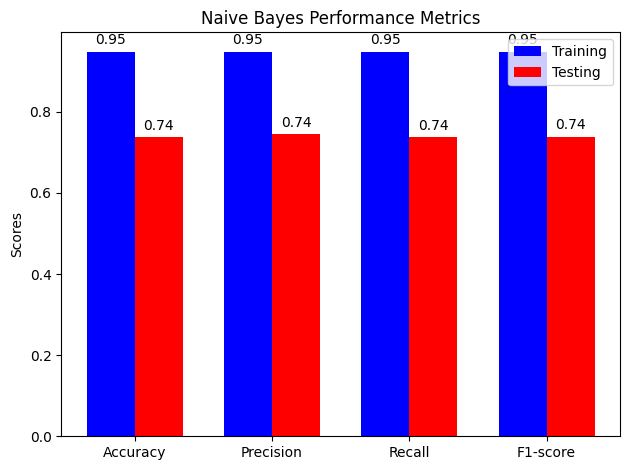

In [ ]:
# Compute precision, recall, and F1-score for training data
train_precision, train_recall, train_f1, _ = precision_recall_fscore_support(y_train, y_train_pred, average='weighted')

# Compute precision, recall, and F1-score for testing data
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')

# Plot the results
labels = ['Accuracy', 'Precision', 'Recall', 'F1-score']
train_scores = [train_accuracy, train_precision, train_recall, train_f1]
test_scores = [accuracy, precision, recall, f1]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots()
train_rects = ax.bar(x - width/2, train_scores, width, label='Training',color='blue')
test_rects = ax.bar(x + width/2, test_scores, width, label='Testing',color='red')

ax.set_ylabel('Scores')
ax.set_title('Naive Bayes Performance Metrics')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate('{:.2f}'.format(height),
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(train_rects)
autolabel(test_rects)

fig.tight_layout()

plt.show()

# Deep Learning

# CNN

In [ ]:
# Preprocess the text data
text_data = df["Title"].tolist()
labels = df["Category"].tolist()

# Split the data into training, validation, and testing sets
X_train, X_test, y_train, y_test = train_test_split(text_data, labels, test_size=0.1, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=42)

# Convert text labels to numerical values
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_val_encoded = label_encoder.transform(y_val)
y_test_encoded = label_encoder.transform(y_test)
num_classes = len(label_encoder.classes_)

# Tokenize the text data and convert to sequences
tokenizer = Tokenizer()
tokenizer.fit_on_texts(X_train)
X_train_sequences = tokenizer.texts_to_sequences(X_train)
X_val_sequences = tokenizer.texts_to_sequences(X_val)
X_test_sequences = tokenizer.texts_to_sequences(X_test)

# Pad sequences to a fixed length
max_sequence_length = 100
X_train_padded = pad_sequences(X_train_sequences, maxlen=max_sequence_length, padding='post')
X_val_padded = pad_sequences(X_val_sequences, maxlen=max_sequence_length, padding='post')
X_test_padded = pad_sequences(X_test_sequences, maxlen=max_sequence_length, padding='post')

# Build the CNN model
model = Sequential()
model.add(Embedding(input_dim=len(tokenizer.word_index) + 1, output_dim=100, input_length=max_sequence_length))
model.add(Conv1D(filters=128, kernel_size=5, activation='relu'))
model.add(GlobalMaxPooling1D())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(num_classes, activation='softmax'))
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Define early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=3)

# Train the model
history = model.fit(X_train_padded, y_train_encoded, validation_data=(X_val_padded, y_val_encoded), epochs=10, batch_size=32,callbacks=[early_stopping])

# Evaluate the model
y_pred = model.predict(X_test_padded)
y_pred_classes = np.argmax(y_pred, axis=1)  # Get the class labels from the predictions
accuracy = accuracy_score(y_test_encoded, y_pred_classes)
print("Accuracy:", accuracy)

Epoch 1/10
114/114 [==============================] - 10s 59ms/step - loss: 1.5157 - accuracy: 0.3514 - val_loss: 1.1780 - val_accuracy: 0.5630
Epoch 2/10
114/114 [==============================] - 4s 37ms/step - loss: 0.6233 - accuracy: 0.8121 - val_loss: 0.7183 - val_accuracy: 0.7556
Epoch 3/10
114/114 [==============================] - 5s 45ms/step - loss: 0.1393 - accuracy: 0.9624 - val_loss: 0.7680 - val_accuracy: 0.7407
Epoch 4/10
114/114 [==============================] - 5s 40ms/step - loss: 0.0356 - accuracy: 0.9931 - val_loss: 0.8760 - val_accuracy: 0.7630
Epoch 5/10
15/15 [==============================] - 0s 10ms/step
Accuracy: 0.7361419068736141


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

# Calculate evaluation metrics
accuracy = accuracy_score(y_test_encoded, y_pred_classes)
classification_report = classification_report(y_test_encoded, y_pred_classes)

# Print evaluation metrics
print("Accuracy:", accuracy)
print("Classification Report:")
print(classification_report)

Accuracy: 0.7361419068736141
Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.75      0.78       107
           1       0.69      0.64      0.66        75
           2       0.71      0.84      0.77        91
           3       0.73      0.78      0.75        85
           4       0.73      0.67      0.70        93

    accuracy                           0.74       451
   macro avg       0.73      0.73      0.73       451
weighted avg       0.74      0.74      0.74       451



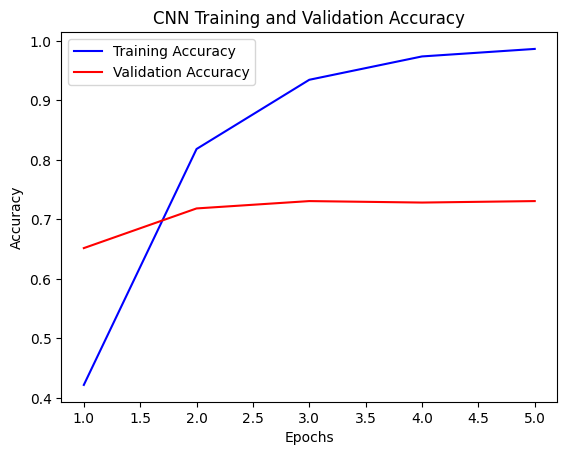

In [ ]:
# Extract the training and validation accuracy from the history object
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

# Plot the training and validation accuracy
epochs = range(1, len(train_accuracy) + 1)
plt.plot(epochs, train_accuracy, 'b', label='Training Accuracy')
plt.plot(epochs, val_accuracy, 'r', label='Validation Accuracy')
plt.title('CNN Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# LSTM

In [ ]:
# Split the dataset into train and test sets
train_df, test_df = train_test_split(df, test_size=0.1, random_state=42)

# Encode the labels
label_encoder = LabelEncoder()
train_labels = label_encoder.fit_transform(train_df['Category'])
test_labels = label_encoder.transform(test_df['Category'])

# Tokenize the text data
tokenizer = Tokenizer()
tokenizer.fit_on_texts(train_df['Title'])
train_sequences = tokenizer.texts_to_sequences(train_df['Title'])
test_sequences = tokenizer.texts_to_sequences(test_df['Title'])

# Pad the sequences to have a consistent length
max_seq_length = 100  # Maximum sequence length for padding
train_data = pad_sequences(train_sequences, maxlen=max_seq_length)
test_data = pad_sequences(test_sequences, maxlen=max_seq_length)

# Create the deep learning model
embedding_dim = 100  # Dimensionality of the word embeddings
vocab_size = len(tokenizer.word_index) + 1  # Vocabulary size
model = Sequential()
model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim))
model.add(SpatialDropout1D(0.2))
model.add(LSTM(128))
model.add(Dense(len(label_encoder.classes_), activation='softmax'))

# Compile the model
model.compile(loss='sparse_categorical_crossentropy', optimizer=Adam(), metrics=['accuracy'])

# Define early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=3)

# Train the model
history = model.fit(train_data, train_labels, validation_split=0.1, epochs=10, batch_size=32, callbacks=[early_stopping])
test_probabilities = model.predict(test_data)
test_predictions = np.argmax(test_probabilities, axis=1)
test_accuracy = accuracy_score(test_labels, test_predictions)
print("Test Accuracy:", test_accuracy)

Epoch 1/10
114/114 [==============================] - 24s 193ms/step - loss: 1.4947 - accuracy: 0.4219 - val_loss: 1.0963 - val_accuracy: 0.6519
Epoch 2/10
114/114 [==============================] - 22s 192ms/step - loss: 0.6611 - accuracy: 0.8184 - val_loss: 0.7708 - val_accuracy: 0.7185
Epoch 3/10
114/114 [==============================] - 21s 182ms/step - loss: 0.2493 - accuracy: 0.9347 - val_loss: 0.7785 - val_accuracy: 0.7309
Epoch 4/10
114/114 [==============================] - 22s 189ms/step - loss: 0.1050 - accuracy: 0.9739 - val_loss: 0.8627 - val_accuracy: 0.7284
Epoch 5/10
15/15 [==============================] - 1s 48ms/step
Test Accuracy: 0.7405764966740577


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, classification_report

# Calculate evaluation metrics
classification_report = classification_report(test_labels, test_predictions)

# Print evaluation metrics
print("Test Accuracy:", test_accuracy)
print("Classification Report:")
print(classification_report)

Test Accuracy: 0.7405764966740577
Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.84      0.81       107
           1       0.68      0.60      0.64        75
           2       0.79      0.81      0.80        91
           3       0.70      0.73      0.71        85
           4       0.73      0.68      0.70        93

    accuracy                           0.74       451
   macro avg       0.73      0.73      0.73       451
weighted avg       0.74      0.74      0.74       451



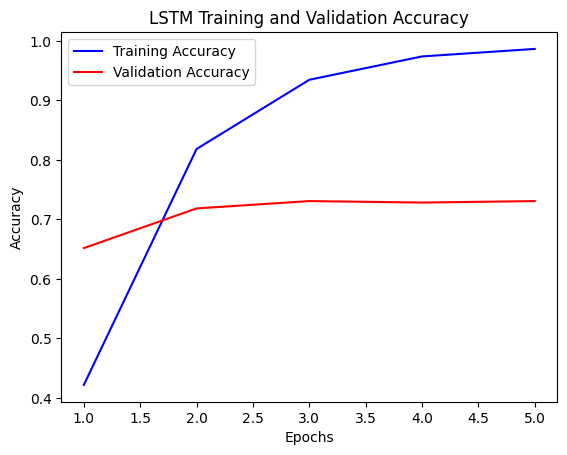

In [ ]:
# Extract the training and validation accuracy from the history object
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

# Plot the training and validation accuracy
epochs = range(1, len(train_accuracy) + 1)
plt.plot(epochs, train_accuracy, 'b', label='Training Accuracy')
plt.plot(epochs, val_accuracy, 'r', label='Validation Accuracy')
plt.title('LSTM Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()